In [1]:
#| default_exp geometry

In [35]:
#| export

import numpy as np
import igl

In [4]:
#| export

import jax
import jax.numpy as jnp

import dataclasses

In [5]:
#| export

from jaxtyping import Float 

In [6]:
#| export

from triangulax import trigonometry as trig
from triangulax import mesh as msh
from triangulax import adjacency as adj

In [7]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [8]:
#| hide

import jaxtyping


In [9]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, %unload_ext jaxtyping 


## Mesh geometry

Using the half-edge mesh and the adjacency-like operators it defines, we can compute all sorts of geometric quantities of interest: edge lengths, cell areas, curvature in 3d, etc.


**Discrete exterior calculus and discrete Hodge star**

Note: triangle area, cell area, edge length, and dual edge lengths are what's required for [discrete exterior calculus](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/paper.pdf).

In [10]:
from triangulax.triangular import TriMesh

In [11]:
# load test data

mesh = TriMesh.read_obj("../test_meshes/disk.obj")
hemesh = msh.HeMesh.from_triangles(mesh.vertices.shape[0], mesh.faces)
geommesh = msh.GeomMesh(*hemesh.n_items, mesh.vertices, mesh.face_positions)

mesh_3d = TriMesh.read_obj("../test_meshes/disk.obj", dim=3)
geommesh_3d = msh.GeomMesh(*hemesh.n_items, mesh_3d.vertices, mesh_3d.face_positions)

  o flat_tri_ecmc
  o flat_tri_ecmc


### Edge lengths, areas, and normals

In [12]:
#| export

def get_he_length(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                  ) -> Float[jax.Array, " n_hes"]:
    """Get lengths of half-edges (triangulation/primal edges)."""
    return jnp.linalg.norm(vertices[hemesh.orig]-vertices[hemesh.dest], axis=-1)


In [14]:
#| export

## triangle areas and normals

def get_triangle_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) -> Float[jax.Array, " n_faces"]:
    """Compute triangle areas in a mesh."""
    return jax.vmap(trig.get_triangle_area)(*vertices[hemesh.faces.T])

def get_barycentric_cell_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                              ) -> Float[jax.Array, " n_vertices"]:
    """Get area of barycentric dual cell around each vertex. Defined as 1/3 * sum of adjacent triangle areas."""
    return adj.sum_face_to_vertex(hemesh, get_triangle_areas(vertices, hemesh)) / 3.0

def get_oriented_triangle_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                                ) -> Float[jax.Array, "n_faces dim"]:
    """Compute oriented triangle areas in a mesh. In 3d, this is a vector."""
    return jax.vmap(trig.get_oriented_triangle_area)(*vertices[hemesh.faces.T])

def get_triangle_normals(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                         ) -> Float[jax.Array, "n_faces dim"]:
    """Compute per-face unit normals. In 2d, this just returns +/-1."""
    oriented_areas = get_oriented_triangle_areas(vertices, hemesh)
    norm = jnp.maximum(jnp.linalg.norm(oriented_areas, axis=-1), 1e-12)
    return (oriented_areas.T / norm).T

def get_vertex_normals(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) -> Float[jax.Array, "n_vertices dim"]:
    """Compute per-vertex unit normals by area-weighted averaging over adjacent faces."""
    oriented_areas = get_oriented_triangle_areas(vertices, hemesh)
    oriented_areas_vertex = adj.sum_face_to_vertex(hemesh, oriented_areas)
    norm = jnp.maximum(jnp.linalg.norm(oriented_areas_vertex, axis=-1), 1e-12)
    return (oriented_areas_vertex.T / norm).T

def get_face_centroids(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) -> Float[jax.Array, "n_faces dim"]:
    """Compute centroids (barycenters) of triangular faces."""
    return vertices[hemesh.faces].mean(axis=1)

def get_dihedral_angles(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) -> Float[jax.Array, " n_hes"]:
    """Get signed dihedral angles (angle between adjacent face normals).
    
    Positive for convex edges, negative for concave. The sign is determined by
    the edge direction
    """
    normals = get_triangle_normals(vertices, hemesh)
    n1 = normals[hemesh.heface]
    n2 = normals[hemesh.heface[hemesh.twin]]
    edge = vertices[hemesh.dest] - vertices[hemesh.orig]
    edge_hat = edge / jnp.maximum(jnp.linalg.norm(edge, axis=-1, keepdims=True), 1e-12)
    sin_theta = jnp.einsum('ei,ei->e', edge_hat, jnp.cross(n1, n2))
    cos_theta = jnp.einsum('ei,ei->e', n1, n2)
    return jnp.arctan2(sin_theta, cos_theta)

### Total volume and surface area

In [13]:
#| export

def get_volume(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
              ) -> Float[jax.Array, ""]:
    """Signed volume of a closed triangulated surface (sums tetrahedra volumes relative to the origin)."""
    v0, v1, v2 = vertices[hemesh.faces.T]
    return trig.get_tetrahedron_volume(v0, v1, v2).sum()

def get_area(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
            ) -> Float[jax.Array, ""]:
    """Total surface area."""
    return get_triangle_areas(vertices, hemesh).sum()

### Dual and Voronoi construction

In [15]:
#| export

def get_voronoi_face_positions(vertices: Float[jax.Array, "n_vertices 2"], hemesh: msh.HeMesh
                               ) -> Float[jax.Array, "n_faces 2"]:
    """Get face positions of geommesh to the circumcenters of the faces defined by hemesh."""
    face_positions = jax.vmap(trig.get_circumcenter)(*vertices[hemesh.faces].transpose((1,0,2)))
    return face_positions

def set_voronoi_face_positions(geommesh: msh.GeomMesh, hemesh: msh.HeMesh
                               ) -> msh.GeomMesh:
    """Set face positions of geommesh to the circumcenters of the faces defined by hemesh."""
    face_positions = get_voronoi_face_positions(geommesh.vertices, hemesh)
    return dataclasses.replace(geommesh, face_positions=face_positions)

In [21]:
#| export

## Note: these quantities are currently accurate in 2D only (i.e. for planar dual cells)
## On the other hand, the dual vertex positions can be arbitrary - they don't have to be circumcenters (Voronoi).

def get_dual_he_length(face_positions: Float[jax.Array, "n_faces dim"], hemesh: msh.HeMesh
                       ) -> Float[jax.Array, " n_hes"]:
    """Get lengths of dual/cell half-edges."""
    dual_edges = face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]]
    return jnp.linalg.norm(dual_edges, axis=-1)

def get_oriented_dual_he_length(vertices: Float[jax.Array, "n_vertices 2"],
                                face_positions: Float[jax.Array, "n_faces 2"],
                                hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Compute lengths of dual edges. Boundary dual edges get length 1. Negative sign = flipped edge."""
    dual_edges = face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]]

    edges = vertices[hemesh.orig]-vertices[hemesh.dest]
    edges_normalized = (edges.T / jnp.linalg.norm(edges, axis=-1)).T
    signed_dual_length = jnp.einsum('vi,vi->v', edges_normalized,
                                    dual_edges @ trig.get_rot_mat(-jnp.pi/2))
    signed_dual_length = jnp.where(hemesh.is_bdry_edge, 1, signed_dual_length)
    return signed_dual_length

In [22]:
a = get_dual_he_length(mesh.face_positions, hemesh)
b = get_oriented_dual_he_length(mesh.vertices, mesh.face_positions, hemesh)

jnp.allclose(a[~hemesh.is_bdry_edge], jnp.abs(b)[~hemesh.is_bdry_edge])

Array(True, dtype=bool)

In [23]:
# edges and dual edges should be orthogonal since we are using circumcenters

face_positions = get_voronoi_face_positions(mesh.vertices, hemesh)

edges = mesh.vertices[hemesh.orig]-mesh.vertices[hemesh.dest]
dual_edges = (face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]])

jnp.allclose(jnp.einsum('vi,vi->v', edges[~hemesh.is_bdry_edge], dual_edges[~hemesh.is_bdry_edge]), 0)

Array(True, dtype=bool)

In [24]:
# computing the signed edge length shows that there are some "flipped" edges.

dual_length = get_oriented_dual_he_length(mesh.vertices, face_positions, hemesh)
jnp.where((dual_length < -0.0) & ~hemesh.is_bdry_edge )[0]

Array([  9, 185, 191, 335, 363, 539, 545, 689], dtype=int64)

### Corner angles, Gaussian curvature, cotangent weights, and Voronoi edge lengths/areas

In [26]:
#| export


def get_corner_angles(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                      ) -> Float[jax.Array, " n_hes"]:
    """Get angles in mesh corners (opposite to half-edges)."""
    b, c = vertices[hemesh.orig], vertices[hemesh.dest]
    a = vertices[hemesh.dest[hemesh.nxt]]
    return jax.vmap(trig.get_angle_between_vectors)(b-a, c-a)


def get_angle_sum(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                  ) -> Float[jax.Array, " n_vertices"]:
    """Angle sum around vertices. ``2*pi - angle_sum`` measures Gaussian curvature."""
    angles = get_corner_angles(vertices, hemesh)
    return adj.sum_he_to_vertex_opposite(hemesh, angles)


def get_cotan_weights_per_he(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Cotangent of angle opposite to half-edge."""
    b, c = vertices[hemesh.orig], vertices[hemesh.dest]
    a = vertices[hemesh.dest[hemesh.nxt]]
    return jax.vmap(trig.get_cot_between_vectors)(b-a, c-a)


def get_cotan_weights_per_edge(vertices: Float[jax.Array, "n_vertices dim"],
                               hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Average of cotangent of angles opposite to edge."""
    per_he = get_cotan_weights_per_he(vertices, hemesh)
    per_he = jnp.where(hemesh.is_bdry_he, 0.0, per_he)
    return (per_he + per_he[hemesh.twin])/2


def get_voronoi_edge_lengths(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Voronoi dual edge lengths computed from cotangent weights. Accurate in any dimension."""
    return get_cotan_weights_per_edge(vertices, hemesh) * get_he_length(vertices, hemesh)


def get_voronoi_edge_areas(vertices: Float[jax.Array, "n_vertices dim"],
                           hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Voronoi "area" for an edge: ``dual_length * primal_length / 4``.

    Summing over all edges adjacent to a vertex gives the Voronoi cell area.
    Computed from cotangent weights. Accurate in any dimension.
    """
    return get_cotan_weights_per_edge(vertices, hemesh) * get_he_length(vertices, hemesh)**2 / 4

In [27]:
angles = get_corner_angles(mesh.vertices, hemesh)

np.allclose(get_angle_sum(mesh.vertices, hemesh)[~hemesh.is_bdry], 2*jnp.pi) # mesh is not curved

True

In [28]:
jnp.allclose(1/jnp.tan(angles), get_cotan_weights_per_he(mesh.vertices, hemesh))

Array(True, dtype=bool)

In [29]:
# we can either compute the Voronoi-length of a dual edge directly, or from the face positions
voronoi_edge_lengths = get_voronoi_edge_lengths(mesh.vertices, hemesh)
dual_edge_length = get_oriented_dual_he_length(mesh.vertices, mesh.face_positions, hemesh)

In [30]:
jnp.allclose(voronoi_edge_lengths[~hemesh.is_bdry_edge], dual_edge_length[~hemesh.is_bdry_edge])

Array(True, dtype=bool)

### Cell areas, perimeters, etc via corners

To compute, for instance, the cell area using the shoelace formula, you need to iterate around the faces adjacent to a vertex. This is not straightforward to vectorize because the number of adjacent faces per vertex can vary (there can be 5-, 6-, 7-sided cells etc.). One way to solve this is a scheme in which the lists of adjacent faces are "padded" in some manner, so that they are all the same length. This is cumbersome.
Instead, let us split all "cell-based" quantities into contributions from "corners", i.e., half-edges, like this:

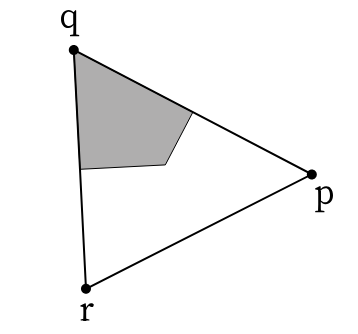
Source: [CGAL](https://doc.cgal.org/latest/Weights/group__PkgWeightsRefVoronoiRegionWeights.html)

To compute the total area, we can sum over all half-edges $(r,p)$ opposite to a vertex $q$. 

Via this approach, one can also compute cell perimeter, etc.

In [31]:
#| export

def get_cell_areas_traversal(geommesh: msh.GeomMesh, hemesh: msh.HeMesh) -> Float[jax.Array, " n_vertices"]:
    """Compute areas of cells by mesh traversal (don't use for simulation, inefficient).

    Boundary vertices get area 0.  The sign flip corrects for the winding
    order of ``iterate_around_vertex`` relative to ``get_polygon_area``.
    """
    areas = jnp.zeros(hemesh.n_vertices)
    bdry = hemesh.is_bdry
    for v in range(hemesh.n_vertices):
        if bdry[v]:
            pass
        else:
            adjacent_faces = hemesh.heface[hemesh.iterate_around_vertex(v)]
            polygon = geommesh.face_positions[adjacent_faces]
            areas = areas.at[v].set(-trig.get_polygon_area(polygon))
    return areas


def get_voronoi_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                      ) -> Float[jax.Array, " n_vertices"]:
    """Compute Voronoi cell area for each vertex by summing edge areas."""
    edge_areas = get_voronoi_edge_areas(vertices, hemesh)
    return adj.sum_he_to_vertex_incoming(hemesh, edge_areas)


def get_voronoi_perimeters(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                           ) -> Float[jax.Array, " n_vertices"]:
    """Compute Voronoi cell perimeter for each vertex by summing dual edge lengths."""
    dual_lengths = get_voronoi_edge_lengths(vertices, hemesh)
    return adj.sum_he_to_vertex_incoming(hemesh, dual_lengths)


def get_gaussian_curvature(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                           ) -> Float[jax.Array, " n_vertices"]:
    """Discrete Gaussian curvature via the angle defect: ``(2π - Σθ_i) / A_i``.

    Uses barycentric dual cell areas.
    """
    angle_defect = 2 * jnp.pi - get_angle_sum(vertices, hemesh)
    cell_areas = get_barycentric_cell_areas(vertices, hemesh)
    return angle_defect / cell_areas

In [32]:
# for comparison, compute the areas by mesh traversal

cell_areas = get_voronoi_areas(geommesh.vertices, hemesh)
cell_areas = cell_areas.at[hemesh.is_bdry].set(0)

cell_areas_iterative = get_cell_areas_traversal(geommesh, hemesh)

print("Voronoi area max error:", jnp.abs(cell_areas_iterative-cell_areas).max())

# Voronoi perimeters
perimeters = get_voronoi_perimeters(mesh.vertices, hemesh)
print("Voronoi perimeters (mean):", perimeters[~hemesh.is_bdry].mean())

# Gaussian curvature should be 0 for a flat disk (interior vertices)
K = get_gaussian_curvature(mesh.vertices, hemesh)
print("Gaussian curvature (max interior):", jnp.abs(K[~hemesh.is_bdry]).max())

# face centroids
centroids = get_face_centroids(mesh.vertices, hemesh)
print("Face centroids shape:", centroids.shape)

Voronoi area max error: 4.85722573273506e-17
Voronoi perimeters (mean): 0.6346395879903053
Gaussian curvature (max interior): 6.078535117627845e-14
Face centroids shape: (224, 2)


### Mean curvature

Two methods are provided for computing pointwise, per-vertex mean curvature.

**Steiner (dihedral angle) formula:**
$$H_i = \frac{1}{4a_i} \sum_{j\sim i} \ell_{ij} \theta_{ij} $$
where $\theta_{ij}$ are the dihedral angles between adjacent triangles, and $a_i$ is the barycentric cell area.

**Cotangent Laplacian formula:** using $\Delta\mathbf{x} = 2H\mathbf{n}$,
$$H_i = -\frac{\mathbf{n}_i \cdot (\Delta\mathbf{x})_i}{2 A_i^{\mathrm{vor}}}$$
where $A_i^{\mathrm{vor}}$ is the Voronoi cell area and $\Delta$ is the cotangent Laplacian.

In [39]:
#| export

def get_mean_curvature_dihedral(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh,
                                normalize: bool = True) ->Float[jax.Array, " n_vertices"]:

    """Compute mean curvature of triangulated mesh using Steiner approximation:
        H_i = 1/(4 A_i) * sum_j * theta_ij * l_ij
    where theta_ij is the dihedral angle between faces adjacent to edge ij, l_ij is the length of edge ij,
    and A_i is the barycentric dual cell area around vertex i.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.
    normalize : bool, optional
        Whether to normalize by the barycentric cell area. If False, returns the integrated mean curvature.

    Returns
    -------
    Float[Array, "n_vertices"]
        Per-vertex mean curvature.

    """
    dihedral_angles = get_dihedral_angles(vertices, hemesh)
    edge_lengths = get_he_length(vertices, hemesh)
    result = adj.sum_he_to_vertex_incoming(hemesh, dihedral_angles*edge_lengths) / 4
    if normalize:
        cell_areas = get_barycentric_cell_areas(vertices, hemesh)
        return result / cell_areas
    return result


def get_mean_curvature_laplace(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh,
                               normalize: bool = True) -> Float[jax.Array, " n_vertices"]:
    """Compute mean curvature from the cotangent Laplacian: ``Δx = 2Hn``.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.
    normalize : bool, optional
        Whether to normalize by the Voronoi cell area. If False, returns the integrated mean curvature.

        
    Returns
    -------
    Float[Array, "n_vertices"]
        Per-vertex mean curvature.
    """
    w_edge = get_cotan_weights_per_edge(vertices, hemesh)
    diff = vertices[hemesh.dest] - vertices[hemesh.orig]    
    l_vec = -adj.sum_he_to_vertex_incoming(hemesh, w_edge[:, None] * diff)
    n_vec = get_vertex_normals(vertices, hemesh)
    result = -jnp.linalg.vecdot(l_vec, n_vec) / 2
    if normalize:
        cell_areas = get_voronoi_areas(vertices, hemesh)
        return result / cell_areas
    return result

In [ ]:
# Test mean curvature on sphere and torus against libigl

# --- Unit sphere ---
v_sphere, f_sphere = igl.read_triangle_mesh("../test_meshes/sphere_fine.obj")
v_sphere = v_sphere / np.linalg.norm(v_sphere, axis=-1, keepdims=True)  # project to unit sphere
hemesh_sphere = msh.HeMesh.from_triangles(v_sphere.shape[0], f_sphere)
v_sphere_jax = jnp.array(v_sphere)

H_dihedral_sphere = get_mean_curvature_dihedral(v_sphere_jax, hemesh_sphere)
H_laplace_sphere = get_mean_curvature_laplace(v_sphere_jax, hemesh_sphere)

_, _, k1_s, k2_s, _ = igl.principal_curvature(v_sphere.astype(np.float64), f_sphere)
H_igl_sphere = (k1_s + k2_s) / 2

print("=== Unit Sphere (H_true = 1.0) ===")
print(f"  igl:      mean={np.mean(np.abs(H_igl_sphere)):.4f},  std={np.std(H_igl_sphere):.4f}")
print(f"  dihedral: mean={float(jnp.mean(jnp.abs(H_dihedral_sphere))):.4f}, std={float(jnp.std(H_dihedral_sphere)):.4f}")
print(f"  laplace:  mean={float(jnp.mean(jnp.abs(H_laplace_sphere))):.4f},  std={float(jnp.std(H_laplace_sphere)):.4f}")

=== Unit Sphere (H_true = 1.0) ===
  igl:      mean=1.1134,  std=0.0033
  dihedral: mean=1.0044, std=0.0196
  laplace:  mean=1.0000,  std=0.0000


  o Icosphere


In [ ]:
# --- Torus ---
v_torus, f_torus = igl.read_triangle_mesh("../test_meshes/torus.obj")
hemesh_torus = msh.HeMesh.from_triangles(v_torus.shape[0], f_torus)
v_torus_jax = jnp.array(v_torus)

H_dihedral_torus = get_mean_curvature_dihedral(v_torus_jax, hemesh_torus)
H_laplace_torus = get_mean_curvature_laplace(v_torus_jax, hemesh_torus)

_, _, k1_t, k2_t, _ = igl.principal_curvature(v_torus.astype(np.float64), f_torus)
H_igl_torus = (k1_t + k2_t) / 2

print("\n=== Torus ===")
print(f"  igl:      mean={np.mean(np.abs(H_igl_torus)):.4f},  range=[{H_igl_torus.min():.4f}, {H_igl_torus.max():.4f}]")
print(f"  dihedral: mean={float(jnp.mean(jnp.abs(H_dihedral_torus))):.4f},  range=[{float(H_dihedral_torus.min()):.4f}, {float(H_dihedral_torus.max()):.4f}]")
print(f"  laplace:  mean={float(jnp.mean(jnp.abs(H_laplace_torus))):.4f},  range=[{float(H_laplace_torus.min()):.4f}, {float(H_laplace_torus.max()):.4f}]")

# Correlation check
corr_dihedral = float(jnp.corrcoef(jnp.array(H_igl_torus), H_dihedral_torus)[0, 1])
corr_laplace = float(jnp.corrcoef(jnp.array(H_igl_torus), H_laplace_torus)[0, 1])
print(f"\n  Correlation with igl:  dihedral={corr_dihedral:.4f},  laplace={corr_laplace:.4f}")


# Note: the IGL quadratic fitting method does indeed give a different result than the Laplacian and dihedral methods (not a bug).
# The difference between Laplace and dihedral methods is mostly due to the area normalization (voronoi vs barycentric).


=== Torus ===
  igl:      mean=2.5613,  range=[1.7344, 4.0399]
  dihedral: mean=2.0051,  range=[1.0084, 3.6089]
  laplace:  mean=1.9372,  range=[1.3435, 2.4066]

  Correlation with igl:  dihedral=0.4923,  laplace=0.6321


  o Torus


### Tangent spaces and parallel transport

This section defines tools to work with the tangent space of a surface, namely:

1. Local orthonormal bases in 3d coordinate-space for the tangent space at each vertex and face.

2. Parallel transport, which in the discrete setting means the rotation matrices that relate the local bases at adjacent triangles or vertices.

Based on [Geometry Central](https://geometry-central.net/surface/geometry/quantities/#tangent-vectors-and-transport).

In [28]:
# load a 3D mesh for testing tangent space functions

sphere = TriMesh.read_obj("../test_meshes/sphere.obj", dim=3)
hemesh_s = msh.HeMesh.from_triangles(sphere.vertices.shape[0], sphere.faces)
geommesh_s = msh.GeomMesh(*hemesh_s.n_items, sphere.vertices, sphere.face_positions)

  o Icosphere


In [29]:
#| export

def get_corner_scaled_angles(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh
                             ) -> Float[jax.Array, " n_hes"]:
    """Corner angles rescaled so they sum to 2π at interior vertices and π at boundary vertices.

    Uses the same indexing convention as `get_corner_angles`: scaled_angles[he] is the
    rescaled angle at vertex dest[nxt[he]] (the vertex opposite halfedge he).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes"]
        Rescaled corner angles per halfedge.
    """
    angles = get_corner_angles(vertices, hemesh)
    angle_sums = adj.sum_he_to_vertex_opposite(hemesh, angles)
    # scale factor: 2π/sum at interior, π/sum at boundary
    target = jnp.where(hemesh.is_bdry, jnp.pi, 2 * jnp.pi)
    scale = target / jnp.clip(angle_sums, 1e-10)
    # corner_angles[he] is the angle at vertex dest[nxt[he]]
    vertex_of_corner = hemesh.dest[hemesh.nxt]
    return angles * scale[vertex_of_corner]

In [30]:
# test: scaled angles should sum to 2π at interior vertices
scaled = get_corner_scaled_angles(geommesh_s.vertices, hemesh_s)
scaled_sums = adj.sum_he_to_vertex_opposite(hemesh_s, scaled)
assert jnp.allclose(scaled_sums[~hemesh_s.is_bdry], 2*jnp.pi, atol=1e-10)

# for disk mesh (has boundary)
scaled_disk = get_corner_scaled_angles(geommesh.vertices, hemesh)
scaled_sums_disk = adj.sum_he_to_vertex_opposite(hemesh, scaled_disk)
assert jnp.allclose(scaled_sums_disk[hemesh.is_bdry], jnp.pi, atol=1e-10)

In [59]:
#| export

def get_face_tangent_basis(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                           ) -> Float[jax.Array, "n_faces 2 dim"]:
    """Orthonormal tangent basis (basisX, basisY) in 3D world coordinates per face.

    Convention: basisX is aligned with the face's incident halfedge projected onto
    the face tangent plane. basisY = cross(basisX, face_normal).

    Note: 3D meshes only (uses cross product).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices 3"]
        Vertex positions in 3D.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_faces 2 3"]
        Per-face tangent basis: result[f, 0] = basisX, result[f, 1] = basisY.
    """
    normals = get_triangle_normals(vertices, hemesh)
    # edge vector of face incident halfedge
    edge_vecs = vertices[hemesh.dest[hemesh.face_incident]] - vertices[hemesh.orig[hemesh.face_incident]]
    # project onto tangent plane and normalize
    basis_X = jax.vmap(trig.project_out_vector)(edge_vecs, normals)
    basis_X = basis_X / jnp.maximum(jnp.linalg.norm(basis_X, axis=-1, keepdims=True), 1e-10)
    basis_Y = jnp.cross(basis_X, normals)
    return jnp.stack([basis_X, basis_Y], axis=1)

In [60]:
# test: face tangent basis orthonormality
face_basis = get_face_tangent_basis(geommesh_s.vertices, hemesh_s)
bx, by = face_basis[:, 0], face_basis[:, 1]
face_normals = get_triangle_normals(geommesh_s.vertices, hemesh_s)

# bx · by ≈ 0, |bx| ≈ 1, |by| ≈ 1
print("Max bx·by:", jnp.abs(jax.vmap(jnp.dot)(bx, by)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx, by), 0., atol=1e-10)
assert jnp.allclose(jnp.linalg.norm(bx, axis=-1), 1., atol=1e-10)
assert jnp.allclose(jnp.linalg.norm(by, axis=-1), 1., atol=1e-10)

# bx and by should be orthogonal to face normal
print("Max bx·n:", jnp.abs(jax.vmap(jnp.dot)(bx, face_normals)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx, face_normals), 0., atol=1e-10)
assert jnp.allclose(jax.vmap(jnp.dot)(by, face_normals), 0., atol=1e-10)

Max bx·by: 9.71445146547012e-17
Max bx·n: 5.93629416659658e-17


In [61]:
#| export

def get_vertex_tangent_basis(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                             ) -> Float[jax.Array, "n_vertices 2 dim"]:
    """Orthonormal tangent basis (basisX, basisY) in 3D world coordinates per vertex.

    Convention: basisX is aligned with the vertex' incident halfedge projected onto
    the vertex tangent plane. basisY = cross(basisX, vertex_normal).

    Note: 3D meshes only (uses cross product).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices 3"]
        Vertex positions in 3D.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_vertices 2 3"]
        Per-vertex tangent basis: result[v, 0] = basisX, result[v, 1] = basisY.
    """
    normals = get_vertex_normals(vertices, hemesh)
    edge_vecs = vertices[hemesh.dest[hemesh.incident]] - vertices[hemesh.orig[hemesh.incident]]
    basis_X = jax.vmap(trig.project_out_vector)(edge_vecs, normals)
    basis_X = basis_X / jnp.maximum(jnp.linalg.norm(basis_X, axis=-1, keepdims=True), 1e-10)
    basis_Y = jnp.cross(basis_X, normals)
    return jnp.stack([basis_X, basis_Y], axis=1)

In [62]:
# test: vertex tangent basis orthonormality
vtx_basis = get_vertex_tangent_basis(geommesh_s.vertices, hemesh_s)
bx_v, by_v = vtx_basis[:, 0], vtx_basis[:, 1]
vtx_normals = get_vertex_normals(geommesh_s.vertices, hemesh_s)

print("Max bx·by:", jnp.abs(jax.vmap(jnp.dot)(bx_v, by_v)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx_v, by_v), 0., atol=1e-8)
assert jnp.allclose(jnp.linalg.norm(bx_v, axis=-1), 1., atol=1e-8)
assert jnp.allclose(jnp.linalg.norm(by_v, axis=-1), 1., atol=1e-8)

# orthogonal to vertex normal
print("Max bx·n:", jnp.abs(jax.vmap(jnp.dot)(bx_v, vtx_normals)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx_v, vtx_normals), 0., atol=1e-8)
assert jnp.allclose(jax.vmap(jnp.dot)(by_v, vtx_normals), 0., atol=1e-8)

Max bx·by: 7.063619505390424e-17
Max bx·n: 1.6653345369377348e-16


#### Parallel transport

To define parallel transport across an edge (between the tangent spaces of two adjacent triangles) or along an edge (between the tangent spaces of two adjacent vertices), we proceed as follows:

1. Find the coordinates of the shared edge vector $\mathbf{e}_{ij} =\mathbf{v}_i-\mathbf{v}_j$ in the two local orthonormal bases, $(x, y)$ and $(x', y')$
2. Compute the (minimal) rotation matrix that maps $(x, y)$ to $(x', y')$. 

This defines two angles $\phi_{ij}^v, \phi_{ij}^f$ for each half-edge, the discrete parallel transport map along ("v") or across ("f") the half edge.

In [89]:
#| export

def get_transport_across_halfedge(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                                  ) -> Float[jax.Array, " n_hes"]:
    """Rotation angle to transport a tangent vector from one face to the adjacent face across a halfedge.

    Applying this rotation to a vector in the frame of heface[he] gives the same vector
    in the frame of heface[twin[he]]. For boundary half edges, this is set to 0
    (no transport since there's only one face).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes"]
        Transport angle per halfedge (radians). NaN for boundary halfedges.
    """
    # get vector of shared half edge in 3d world coordinates
    edge_vec = vertices[hemesh.orig] - vertices[hemesh.dest]
    # get tangent basis
    face_basis = get_face_tangent_basis(vertices, hemesh)
    # project edge vector onto face and twin bases
    edge_vec_face = jnp.einsum('vix, vx -> vi', face_basis[hemesh.heface], edge_vec)
    edge_vec_face_twin = jnp.einsum('vix, vx -> vi', face_basis[hemesh.heface[hemesh.twin]], edge_vec)
    # get angle between the two
    transport_angle = jax.vmap(trig.get_angle_between_vectors)(edge_vec_face, -edge_vec_face_twin)
    # mask boundary halfedges
    transport_angle = jnp.where(hemesh.is_bdry_edge, 0, transport_angle)
    return transport_angle

In [97]:
transports = get_transport_across_halfedge(geommesh_s.vertices, hemesh_s)
jnp.allclose(transports - transports[hemesh_s.twin], 0)

Array(True, dtype=bool)

In [91]:
#| export

def get_transport_along_halfedge(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                                 ) -> Float[jax.Array, " n_hes"]:
    """Rotation angle to transport a tangent vector from one vertex to the next vertex along a halfedge.

    Applying this rotation to a vector in the frame of a vertex gives the same vector
    in the frame of the next vertex along the halfedge

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes"]
        Transport angle per halfedge (radians). NaN for boundary halfedges.
    """
    # get vector of shared half edge in 3d world coordinates
    edge_vec = vertices[hemesh.orig] - vertices[hemesh.dest]
    # get tangent basis
    vertex_basis = get_vertex_tangent_basis(vertices, hemesh)
    # project edge vector onto vertex bases
    edge_vec_vertex = jnp.einsum('vix, vx -> vi', vertex_basis[hemesh.orig], edge_vec)
    edge_vec_vertex_next = jnp.einsum('vix, vx -> vi', vertex_basis[hemesh.dest], edge_vec)
    # get angle between the two
    transport_angle = jax.vmap(trig.get_angle_between_vectors)(edge_vec_vertex, -edge_vec_vertex_next)
    # mask boundary halfedges
    transport_angle = jnp.where(hemesh.is_bdry_edge, 0, transport_angle)
    return transport_angle

In [93]:
transports = get_transport_along_halfedge(geommesh_s.vertices, hemesh_s)
jnp.allclose(transports - transports[hemesh_s.twin], 0)